# PCA con Prince

Datos numéricos desde una URL pública (Iris). Incluye: varianza explicada, plano principal (F1–F2), círculo de correlaciones, biplot, contribuciones y cos².

In [ ]:
%pip install prince pandas matplotlib seaborn altair -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import prince  #libreria para analisis de componentes principales pca

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 5)

## 1. Cargar datos (URL)

In [ ]:
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"  #iris esun dataset para aprendizaje supervisado, pero se va a aplicar aqui, es de los mas sencillos para clusters
df = pd.read_csv(URL)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
y = df["species"]
X = df.drop(columns=["species"])
X.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Ajustar PCA (Prince)

`engine='scipy'` evita la aleatoriedad del SVD aleatorizado en datasets pequeños.

In [ ]:
n_comp = min(4, X.shape[1])     #aqui le digo a cuantos componentes quiero que se reduzca, estoy utilizando 4
pca = prince.PCA(
    n_components=n_comp,  #componente principal cuantos parametros quiero
    rescale_with_mean=True,
    rescale_with_std=True,
    engine="scipy",
    copy=True,
)
pca = pca.fit(X)    #aqui defino fit
pca.eigenvalues_summary
#con el componente 0 y 1 logro tener el 95.81% de la data

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,2.918,72.96%,72.96%
1,0.914,22.85%,95.81%
2,0.147,3.67%,99.48%
3,0.021,0.52%,100.00%


## 3. Varianza explicada (barras + acumulado)

También puedes usar `pca.scree_plot()` si tienes Altair bien configurado en Jupyter.

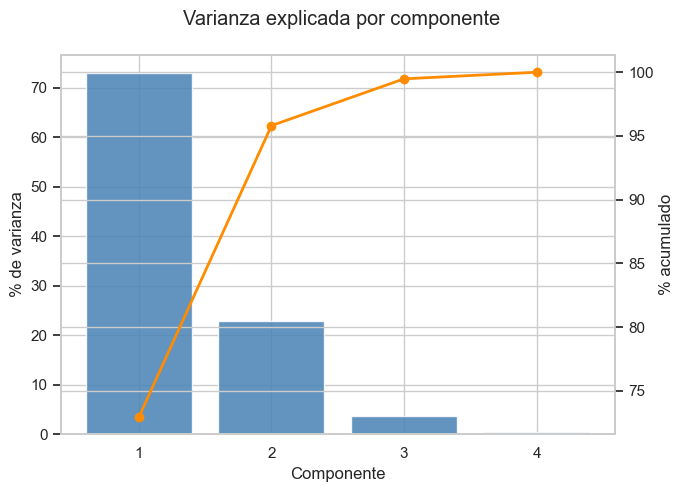

In [ ]:
pct = pca.percentage_of_variance_
cum = pca.cumulative_percentage_of_variance_
comps = np.arange(1, len(pct) + 1)

fig, ax1 = plt.subplots()
ax1.bar(comps, pct, color="steelblue", alpha=0.85, label="% varianza")
ax1.set_xlabel("Componente")
ax1.set_ylabel("% de varianza")
ax2 = ax1.twinx()
ax2.plot(comps, cum, "o-", color="darkorange", lw=2, label="% acumulado")
ax2.set_ylabel("% acumulado")
ax1.set_xticks(comps)
fig.suptitle("Varianza explicada por componente")
fig.tight_layout()
plt.show()
#similar a un grafico de pareto

## 4. Plano principal (individuos en F1–F2)

Coordenadas de filas = `pca.transform(X)` (scores).

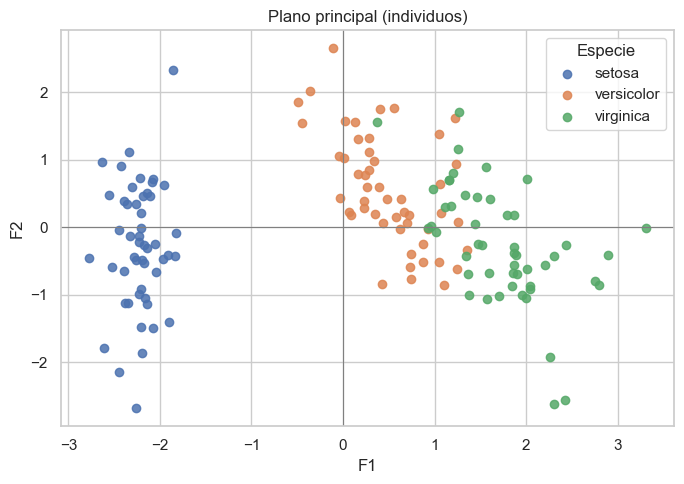

In [ ]:
coords = pca.transform(X)
plt.figure()
for sp in y.unique():
    m = y == sp
    plt.scatter(coords.loc[m, 0], coords.loc[m, 1], label=sp, alpha=0.85)
plt.axhline(0, color="gray", lw=0.8)
plt.axvline(0, color="gray", lw=0.8)
plt.xlabel("F1")
plt.ylabel("F2")
plt.title("Plano principal (individuos)")
plt.legend(title="Especie")
plt.tight_layout()
plt.show()
#un scater para graficar los puntos

## 5. Círculo de correlaciones (variables × F1, F2)

En PCA estandarizada, `pca.column_correlations` coincide con las correlaciones variable–componente; el círculo unidad marca el máximo teórico por componente.

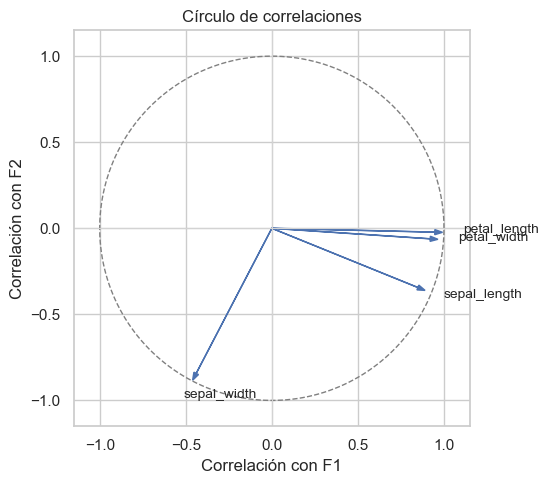

In [ ]:
R = pca.column_correlations[[0, 1]]
fig, ax = plt.subplots()
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color="gray", ls="--", lw=1)
ax.axhline(0, color="lightgray", lw=0.8)
ax.axvline(0, color="lightgray", lw=0.8)
for var, row in R.iterrows():
    ax.arrow(0, 0, row[0], row[1], length_includes_head=True, head_width=0.03, fc="C0", ec="C0")
    ax.text(row[0] * 1.12, row[1] * 1.12, str(var), fontsize=10)
ax.set_aspect("equal")
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel("Correlación con F1")
ax.set_ylabel("Correlación con F2")
ax.set_title("Círculo de correlaciones")
plt.tight_layout()
plt.show()
#son muy parecidas por el petalo

## 6. Biplot

Primero el gráfico interactivo de Prince (Altair). Debajo, el mismo plano con **matplotlib** por si el visor no muestra Altair.

**Nota:** `pca.plot` solo usa las variables con las que se ajustó el PCA; una columna `species` extra no entra en el gráfico y Altair falla al colorear. Pon la clase en el **índice** con nombre `species` (texto) para que `color_rows_by` funcione.

In [ ]:
X_plot = X.copy()
X_plot.index = pd.Index(y.astype(str).to_numpy(), name="species")
pca.plot(
    X_plot,
    x_component=0,
    y_component=1,
    color_rows_by="species",
    show_row_markers=True,
    show_column_markers=True,
    show_row_labels=False,
    show_column_labels=True,
)

c:\Users\alopez\AppData\Local\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\alopez\AppData\Local\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\alopez\AppData\Local\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\alopez\

alt.LayerChart(...)

### Biplot con matplotlib (respaldo visual)

Puntos = individuos (F1, F2); flechas = variables (correlaciones con F1 y F2, escaladas solo para que quepan en el mismo gráfico).

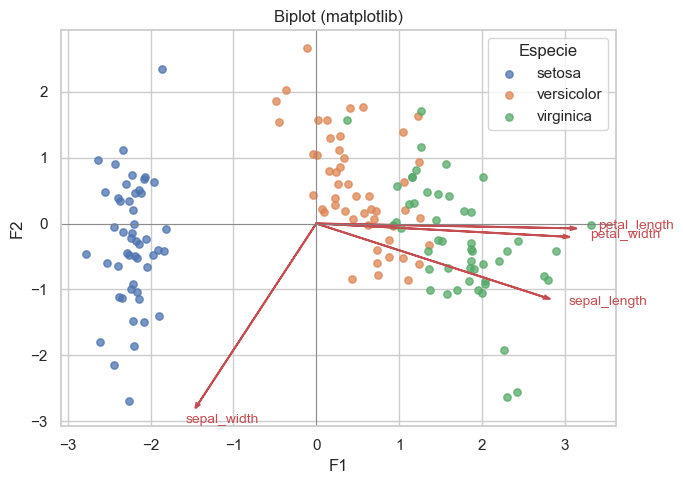

In [ ]:
rows = pca.transform(X)[[0, 1]]
L = pca.column_correlations[[0, 1]]
scale = 0.95 * np.max(np.abs(rows.values)) / np.max(np.abs(L.values))
plt.figure(figsize=(7, 5))
for sp in y.unique():
    m = y == sp
    plt.scatter(rows.loc[m, 0], rows.loc[m, 1], label=sp, alpha=0.75, s=28)
for var, row in L.iterrows():
    plt.arrow(
        0,
        0,
        row[0] * scale,
        row[1] * scale,
        color="C3",
        length_includes_head=True,
        head_width=0.05,
        lw=1.4,
    )
    plt.text(row[0] * scale * 1.08, row[1] * scale * 1.08, str(var), color="C3", fontsize=10)
plt.axhline(0, color="gray", lw=0.6)
plt.axvline(0, color="gray", lw=0.6)
plt.xlabel("F1")
plt.ylabel("F2")
plt.title("Biplot (matplotlib)")
plt.legend(title="Especie")
plt.tight_layout()
plt.show()

## 7. Contribuciones (filas y columnas)

Qué parte de cada componente “explica” cada individuo o cada variable (según inercia). Valores en **tablas** (porcentaje), más fáciles de leer que un mapa de color.

In [ ]:
from IPython.display import Markdown, display

display(Markdown("#### Contribución de variables (%)"))
display(pca.column_contributions_.style.format("{:.1%}").set_caption("Porcentaje de inercia de cada variable en cada componente"))
#las 4 columnas estan bien representadas

#### Contribución de variables (%)

component,0,1,2,3
variable,,,,
sepal_length,27.2%,14.2%,51.8%,6.8%
sepal_width,7.3%,85.2%,6.0%,1.5%
petal_length,33.7%,0.1%,2.0%,64.2%
petal_width,31.9%,0.4%,40.2%,27.4%


## 8. cos² (calidad de representación en cada eje)

Para **columnas**, cos² = correlación² (misma tabla que `column_correlations ** 2`). Para **filas**, `pca.row_cosine_similarities(X)`. Misma idea: **tablas** en lugar de heatmaps.

In [ ]:
from IPython.display import Markdown, display

row_cos2 = pca.row_cosine_similarities(X).astype(float)
display(Markdown("#### cos² filas — primeras 25 de 150"))
display(row_cos2.head(25).style.format("{:.3f}").set_caption("Qué tan bien representado está cada individuo en cada eje"))
#tabla de cosenos como estan representados los componentes

#### cos² filas — primeras 25 de 150

component,0,1,2,3
0,0.954,0.043,0.003,0.000
1,0.893,0.094,0.011,0.002
2,0.979,0.020,0.000,0.000
3,0.935,0.063,0.001,0.001
4,0.932,0.068,0.000,0.000
5,0.660,0.340,0.000,0.000
6,0.981,0.000,0.018,0.000
7,0.988,0.010,0.002,0.000
8,0.812,0.185,0.003,0.000
9,0.943,0.043,0.013,0.000
